Computing matter transfer function with CLASS...


/tmp/ipykernel_111714/1714912593.py:105: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


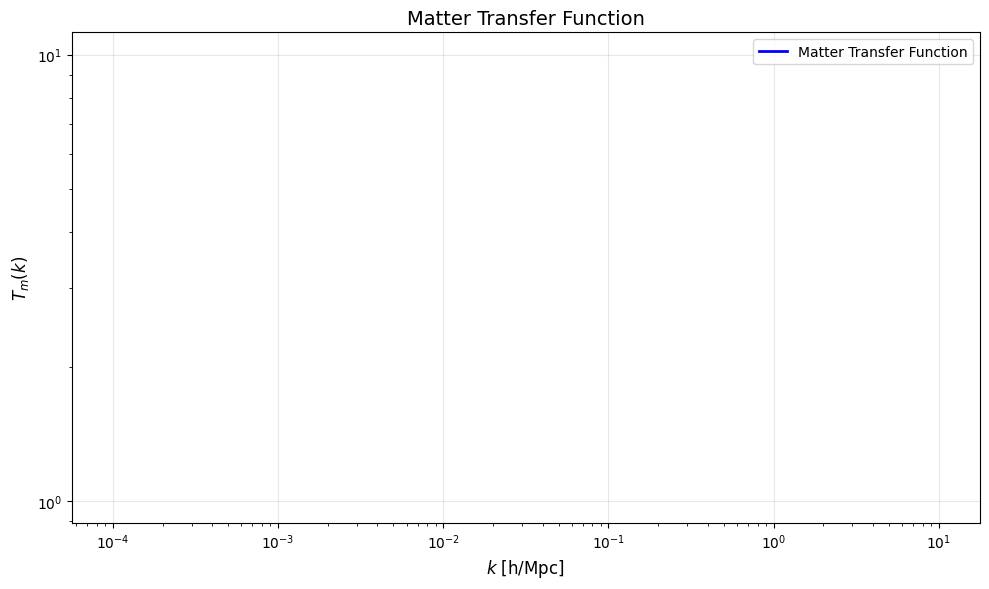

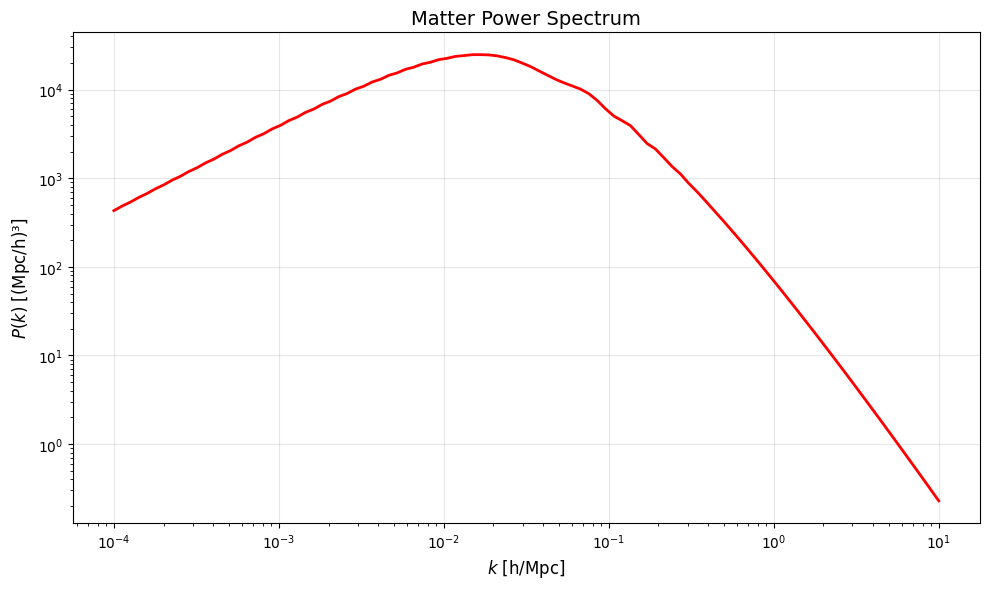


Comparing different cosmological models...


/tmp/ipykernel_111714/1714912593.py:145: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


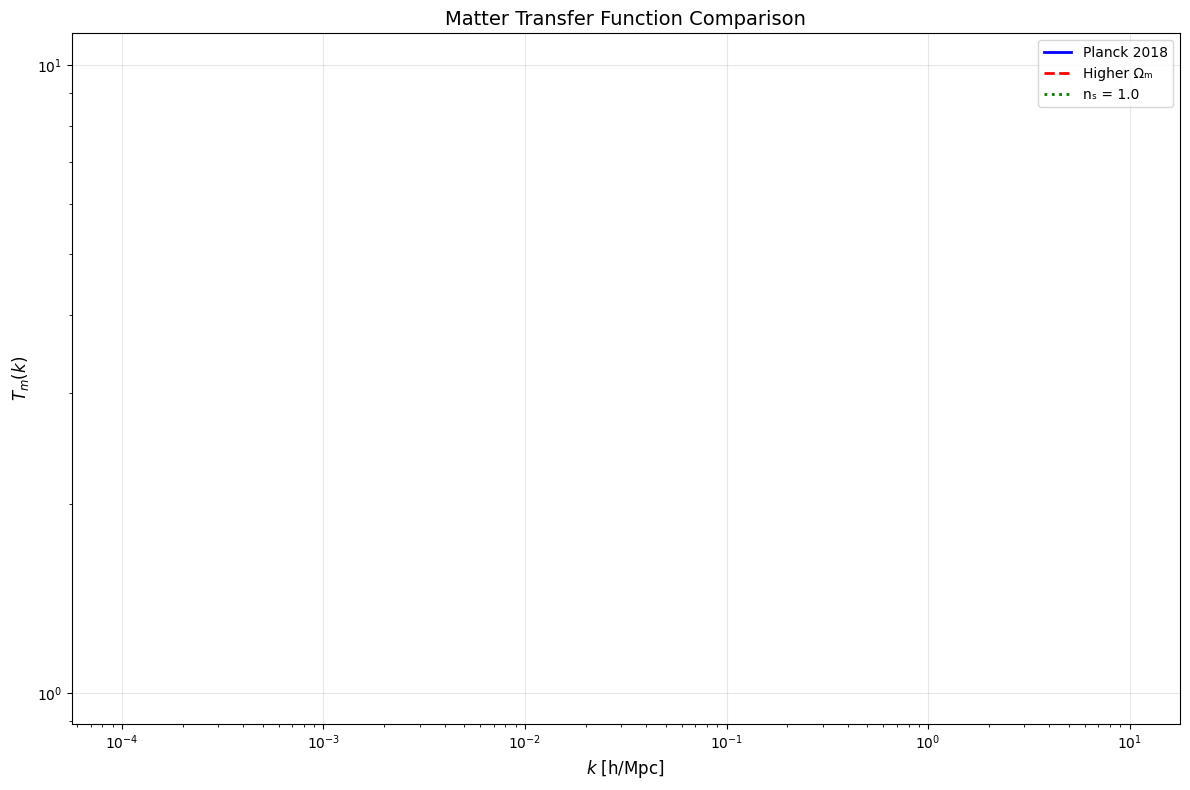


Transfer function at k=0.1 h/Mpc: T_m = -11728.9043
Transfer function at k=1.0 h/Mpc: T_m = -42821.9693


In [2]:

"""
Matter Transfer Function Calculation using CLASS
===============================================

This script demonstrates how to compute matter transfer functions
using the CLASS (Cosmic Linear Anisotropy Solving System) code.

Requirements:
- classy (Python wrapper for CLASS)
- numpy
- matplotlib

Install with: pip install classy numpy matplotlib
"""

import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

def compute_transfer_function(cosmology_params=None, k_range=(1e-4, 10), n_k=100):
    """
    Compute matter transfer function using CLASS
    
    Parameters:
    -----------
    cosmology_params : dict
        Cosmological parameters. If None, uses Planck 2018 values.
    k_range : tuple
        Range of k values in h/Mpc (k_min, k_max)
    n_k : int
        Number of k points
    
    Returns:
    --------
    k : array
        Wavenumbers in h/Mpc
    T_m : array
        Matter transfer function (dimensionless)
    """
    
    # Default cosmological parameters (Planck 2018)
    if cosmology_params is None:
        cosmology_params = {
            'h': 0.6736,                    # Hubble parameter
            'omega_b': 0.02237,             # Baryon density parameter
            'omega_cdm': 0.1200,            # Cold dark matter density
            'A_s': 2.1e-9,                  # Scalar amplitude
            'n_s': 0.9649,                  # Spectral index
            'tau_reio': 0.0544,             # Reionization optical depth
        }
    
    # Initialize CLASS
    cosmo = Class()
    
    # Set parameters for transfer function calculation
    class_params = cosmology_params.copy()
    class_params.update({
        'output': 'mTk',                    # Request matter transfer functions
        'P_k_max_h/Mpc': k_range[1],       # Maximum k for computation
        'z_max_pk': 0.0,                   # Maximum redshift (0 for present)
    })
    
    # Set parameters and compute
    cosmo.set(class_params)
    cosmo.compute()
    
    # Generate k array
    k = np.logspace(np.log10(k_range[0]), np.log10(k_range[1]), n_k)
    
    # Get transfer functions at z=0
    transfer_data = []
    for k_val in k:
        # Get transfer function (returns dictionary with different components)
        tk_dict = cosmo.get_transfer(z=0.0, output_format='dict')
        
        # For the first call, store the k values from CLASS
        if len(transfer_data) == 0:
            k_class = tk_dict['k (h/Mpc)']
            T_m_class = tk_dict['d_m']  # Matter transfer function
            break
    
    # Interpolate to desired k range
    T_m = np.interp(k, k_class, T_m_class)
    
    # Clean up
    cosmo.struct_cleanup()
    cosmo.empty()
    
    return k, T_m

def plot_transfer_function(k, T_m, title="Matter Transfer Function"):
    """
    Plot the matter transfer function
    """
    plt.figure(figsize=(10, 6))
    plt.loglog(k, T_m, 'b-', linewidth=2, label='Matter Transfer Function')
    plt.xlabel(r'$k$ [h/Mpc]', fontsize=12)
    plt.ylabel(r'$T_m(k)$', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compare_cosmologies():
    """
    Compare transfer functions for different cosmological models
    """
    # Standard ΛCDM (Planck 2018)
    planck_params = {
        'h': 0.6736,
        'omega_b': 0.02237,
        'omega_cdm': 0.1200,
        'A_s': 2.1e-9,
        'n_s': 0.9649,
        'tau_reio': 0.0544,
    }
    
    # Higher matter density
    high_matter_params = planck_params.copy()
    high_matter_params['omega_cdm'] = 0.15
    
    # Different spectral index
    different_ns_params = planck_params.copy()
    different_ns_params['n_s'] = 1.0
    
    # Compute transfer functions
    k, T_planck = compute_transfer_function(planck_params)
    _, T_high_matter = compute_transfer_function(high_matter_params)
    _, T_different_ns = compute_transfer_function(different_ns_params)
    
    # Plot comparison
    plt.figure(figsize=(12, 8))
    plt.loglog(k, T_planck, 'b-', linewidth=2, label='Planck 2018')
    plt.loglog(k, T_high_matter, 'r--', linewidth=2, label='Higher Ωₘ')
    plt.loglog(k, T_different_ns, 'g:', linewidth=2, label='nₛ = 1.0')
    plt.xlabel(r'$k$ [h/Mpc]', fontsize=12)
    plt.ylabel(r'$T_m(k)$', fontsize=12)
    plt.title('Matter Transfer Function Comparison', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def power_spectrum_from_transfer(k, T_m, A_s=2.1e-9, n_s=0.9649, h=0.6736):
    """
    Compute matter power spectrum from transfer function
    
    P(k) = A_s * (k/k_pivot)^(n_s-1) * T_m(k)^2 * (2π²/k³) * growth_factor²
    """
    k_pivot = 0.05  # Pivot scale in Mpc⁻¹
    
    # Convert k from h/Mpc to Mpc⁻¹
    k_mpc = k * h
    
    # Primordial power spectrum (simplified, ignoring running)
    P_primordial = A_s * (k_mpc / k_pivot)**(n_s - 1)
    
    # Matter power spectrum (at z=0, so growth factor = 1)
    # Factor of 2π²/k³ converts from dimensionless to [Mpc/h]³
    P_matter = P_primordial * T_m**2 * (2 * np.pi**2) / k**3
    
    return P_matter

def main():
    """
    Main execution function
    """
    print("Computing matter transfer function with CLASS...")
    
    # Compute transfer function
    k, T_m = compute_transfer_function()
    
    # Plot transfer function
    plot_transfer_function(k, T_m)
    
    # Compute and plot power spectrum
    P_k = power_spectrum_from_transfer(k, T_m)
    
    plt.figure(figsize=(10, 6))
    plt.loglog(k, P_k, 'r-', linewidth=2)
    plt.xlabel(r'$k$ [h/Mpc]', fontsize=12)
    plt.ylabel(r'$P(k)$ [(Mpc/h)³]', fontsize=12)
    plt.title('Matter Power Spectrum', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Compare different cosmologies
    print("\nComparing different cosmological models...")
    compare_cosmologies()
    
    # Print some key values
    print(f"\nTransfer function at k=0.1 h/Mpc: T_m = {np.interp(0.1, k, T_m):.4f}")
    print(f"Transfer function at k=1.0 h/Mpc: T_m = {np.interp(1.0, k, T_m):.4f}")

main()

In [3]:
"""
Main execution function
"""
print("Computing matter transfer function with CLASS...")

# Compute transfer function
k, T_m = compute_transfer_function()



# Compute and plot power spectrum
P_k = power_spectrum_from_transfer(k, T_m)

Computing matter transfer function with CLASS...


In [4]:
T_m

array([-9.08289808e-02, -1.15040629e-01, -1.44568314e-01, -1.83192966e-01,
       -2.30090656e-01, -2.91699914e-01, -3.66177103e-01, -4.64429433e-01,
       -5.82683852e-01, -7.39328788e-01, -9.27041079e-01, -1.17667845e+00,
       -1.47452319e+00, -1.87211988e+00, -2.34442980e+00, -2.97714724e+00,
       -3.72548354e+00, -4.73120258e+00, -5.91551214e+00, -7.51166753e+00,
       -9.38305931e+00, -1.19110994e+01, -1.48621274e+01, -1.88550770e+01,
       -2.34957373e+01, -2.97798840e+01, -3.70515766e+01, -4.68955988e+01,
       -5.82372195e+01, -7.35660843e+01, -9.11513796e+01, -1.14842195e+02,
       -1.41906512e+02, -1.78176551e+02, -2.19443639e+02, -2.74320271e+02,
       -3.36517719e+02, -4.18317685e+02, -5.10701445e+02, -6.30299035e+02,
       -7.64989330e+02, -9.35385502e+02, -1.12719582e+03, -1.36131157e+03,
       -1.62475980e+03, -1.93176457e+03, -2.27615280e+03, -2.65538311e+03,
       -3.07855383e+03, -3.52047108e+03, -4.01278446e+03, -4.52938310e+03,
       -5.11265893e+03, -

In [7]:
cosmology_params = {
    'h': 0.6736,                    # Hubble parameter
    'omega_b': 0.02237,             # Baryon density parameter
    'omega_cdm': 0.1200,            # Cold dark matter density
    'A_s': 2.1e-9,                  # Scalar amplitude
    'n_s': 0.9649,                  # Spectral index
    'tau_reio': 0.0544,             # Reionization optical depth
}

k_range=(1e-4, 10)

n_k=100

# Initialize CLASS
cosmo = Class()

# Set parameters for transfer function calculation
class_params = cosmology_params.copy()
class_params.update({
    'output': 'mTk',                    # Request matter transfer functions
    'P_k_max_h/Mpc': k_range[1],       # Maximum k for computation
    'z_max_pk': 0.0,                   # Maximum redshift (0 for present)
})

# Set parameters and compute
cosmo.set(class_params)
cosmo.compute()

# Generate k array
k = np.logspace(np.log10(k_range[0]), np.log10(k_range[1]), n_k)

# Get transfer functions at z=0
transfer_data = []

for k_val in k:
    # Get transfer function (returns dictionary with different components)
    tk_dict = cosmo.get_transfer(z=0.0, output_format='dict')
    
    # For the first call, store the k values from CLASS
    if len(transfer_data) == 0:
        k_class = tk_dict['k (h/Mpc)']
        T_m_class = tk_dict['d_m']  # Matter transfer function
        break

# Interpolate to desired k range
T_m = np.interp(k, k_class, T_m_class)

# Clean up
cosmo.struct_cleanup()
cosmo.empty()
